In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/dft_traffic_counts_aadf.csv')

# First look
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
df.head()

C:\Users\dell\AppData\Local\Temp\ipykernel_5028\2219533349.py:8: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/dft_traffic_counts_aadf.csv')


Shape: (555880, 34)

Columns:
 ['count_point_id', 'year', 'region_id', 'region_name', 'region_ons_code', 'local_authority_id', 'local_authority_name', 'local_authority_code', 'road_name', 'road_category', 'road_type', 'start_junction_road_name', 'end_junction_road_name', 'easting', 'northing', 'latitude', 'longitude', 'link_length_km', 'link_length_miles', 'estimation_method', 'estimation_method_detailed', 'pedal_cycles', 'two_wheeled_motor_vehicles', 'cars_and_taxis', 'buses_and_coaches', 'LGVs', 'HGVs_2_rigid_axle', 'HGVs_3_rigid_axle', 'HGVs_4_or_more_rigid_axle', 'HGVs_3_or_4_articulated_axle', 'HGVs_5_articulated_axle', 'HGVs_6_articulated_axle', 'all_HGVs', 'all_motor_vehicles']


,count_point_id,year,region_id,region_name,region_ons_code,local_authority_id,local_authority_name,local_authority_code,road_name,road_category,...,buses_and_coaches,LGVs,HGVs_2_rigid_axle,HGVs_3_rigid_axle,HGVs_4_or_more_rigid_axle,HGVs_3_or_4_articulated_axle,HGVs_5_articulated_axle,HGVs_6_articulated_axle,all_HGVs,all_motor_vehicles
0,51,2000,1,South West,E12000009,1,Isles of Scilly,E06000053,A3111,PA,...,25,451,30,0,0,0,0,0,30,1430
1,51,2001,1,South West,E12000009,1,Isles of Scilly,E06000053,A3111,PA,...,27,451,28,0,0,0,0,0,28,1446
2,51,2002,1,South West,E12000009,1,Isles of Scilly,E06000053,A3111,PA,...,28,467,28,0,0,0,0,0,28,1518
3,51,2003,1,South West,E12000009,1,Isles of Scilly,E06000053,A3111,PA,...,29,509,27,0,0,0,0,0,27,1622
4,51,2004,1,South West,E12000009,1,Isles of Scilly,E06000053,A3111,PA,...,35,296,77,6,0,1,0,0,84,928


In [2]:
# Reload with fix for the warning
df = pd.read_csv('../data/dft_traffic_counts_aadf.csv', low_memory=False)

# Check data types and missing values
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
count_point_id                    int64
year                              int64
region_id                         int64
region_name                      object
region_ons_code                  object
local_authority_id                int64
local_authority_name             object
local_authority_code             object
road_name                        object
road_category                    object
road_type                        object
start_junction_road_name         object
end_junction_road_name           object
easting                           int64
northing                          int64
latitude                        float64
longitude                       float64
link_length_km                  float64
link_length_miles               float64
estimation_method                object
estimation_method_detailed       object
pedal_cycles                      int64
two_wheeled_motor_vehicles        int64
cars_and_taxis                    int64
buses_and_coaches           

In [3]:
# Check the important columns for our project
key_cols = ['year', 'region_name', 'road_category', 
            'all_motor_vehicles', 'all_HGVs', 
            'cars_and_taxis', 'LGVs']

print(df[key_cols].describe())

               year  all_motor_vehicles       all_HGVs  cars_and_taxis  \
count  555880.00000       555880.000000  555880.000000   555880.000000   
mean     2011.80485        16794.728463     956.382581    13262.188301   
std         6.80365        20346.997517    2214.428381    15511.178418   
min      2000.00000            0.000000       0.000000        0.000000   
25%      2006.00000         4652.000000     101.000000     3705.000000   
50%      2012.00000        11433.000000     318.000000     9217.000000   
75%      2018.00000        20322.000000     760.000000    16381.000000   
max      2023.00000       262842.000000   31198.000000   207133.000000   

                LGVs  
count  555880.000000  
mean     2228.884851  
std      2958.751864  
min         0.000000  
25%       597.000000  
50%      1431.000000  
75%      2584.000000  
max     43692.000000  


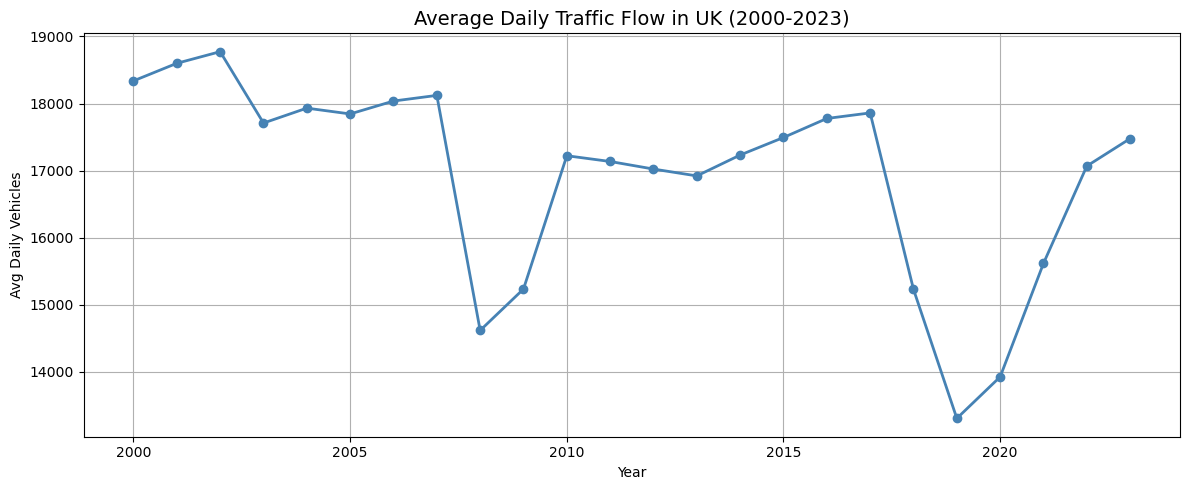

Chart saved!


In [4]:
# Total traffic trend over years
yearly = df.groupby('year')['all_motor_vehicles'].mean().reset_index()

plt.figure(figsize=(12,5))
plt.plot(yearly['year'], yearly['all_motor_vehicles'], 
         marker='o', color='steelblue', linewidth=2)
plt.title('Average Daily Traffic Flow in UK (2000-2023)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Avg Daily Vehicles')
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/01_traffic_trend.png')
plt.show()
print("Chart saved!")

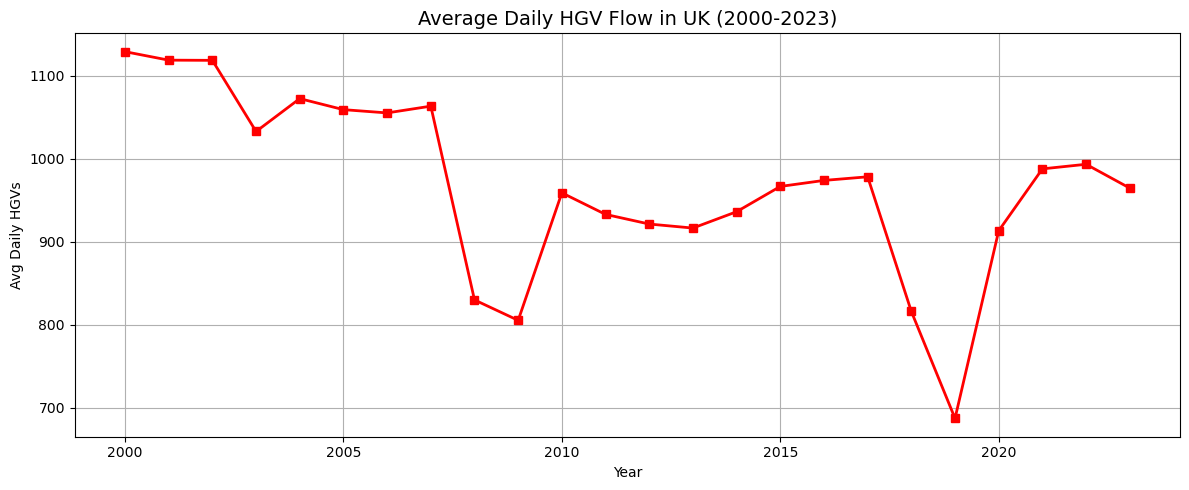

Chart saved!


In [5]:
# HGV trend over years
yearly_hgv = df.groupby('year')['all_HGVs'].mean().reset_index()

plt.figure(figsize=(12,5))
plt.plot(yearly_hgv['year'], yearly_hgv['all_HGVs'], 
         marker='s', color='red', linewidth=2)
plt.title('Average Daily HGV Flow in UK (2000-2023)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Avg Daily HGVs')
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/02_hgv_trend.png')
plt.show()
print("Chart saved!")

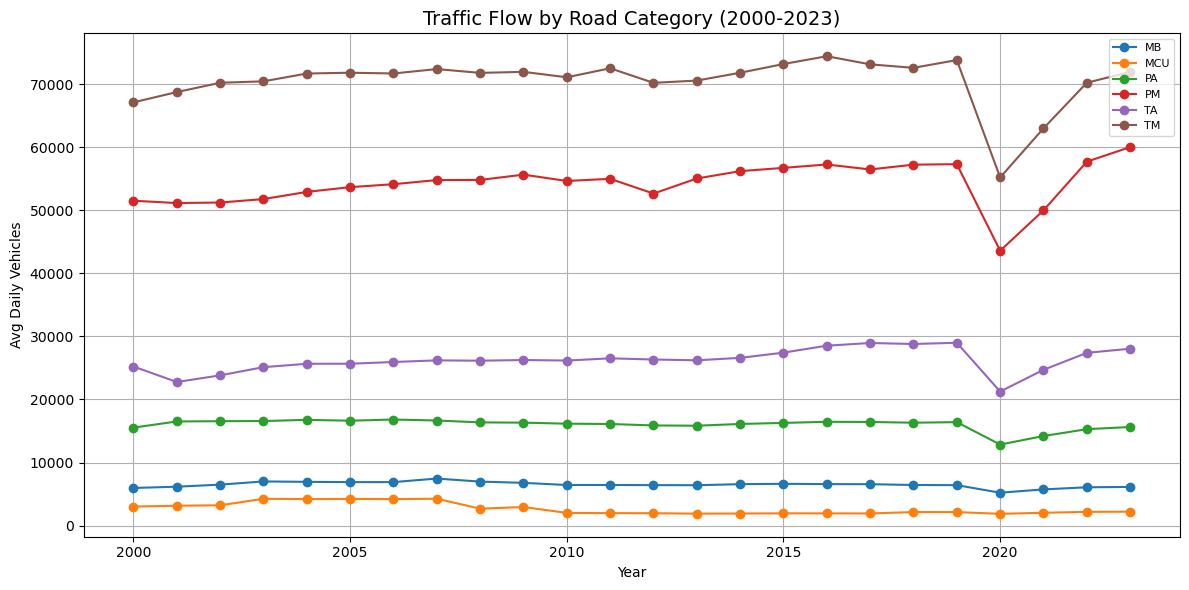

In [6]:
# Urban vs Rural traffic comparison
urban_rural = df.groupby(['year', 'road_category'])['all_motor_vehicles'].mean().reset_index()

plt.figure(figsize=(12,6))
for category in urban_rural['road_category'].unique():
    data = urban_rural[urban_rural['road_category'] == category]
    plt.plot(data['year'], data['all_motor_vehicles'], marker='o', label=category)

plt.title('Traffic Flow by Road Category (2000-2023)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Avg Daily Vehicles')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/03_urban_rural.png')
plt.show()

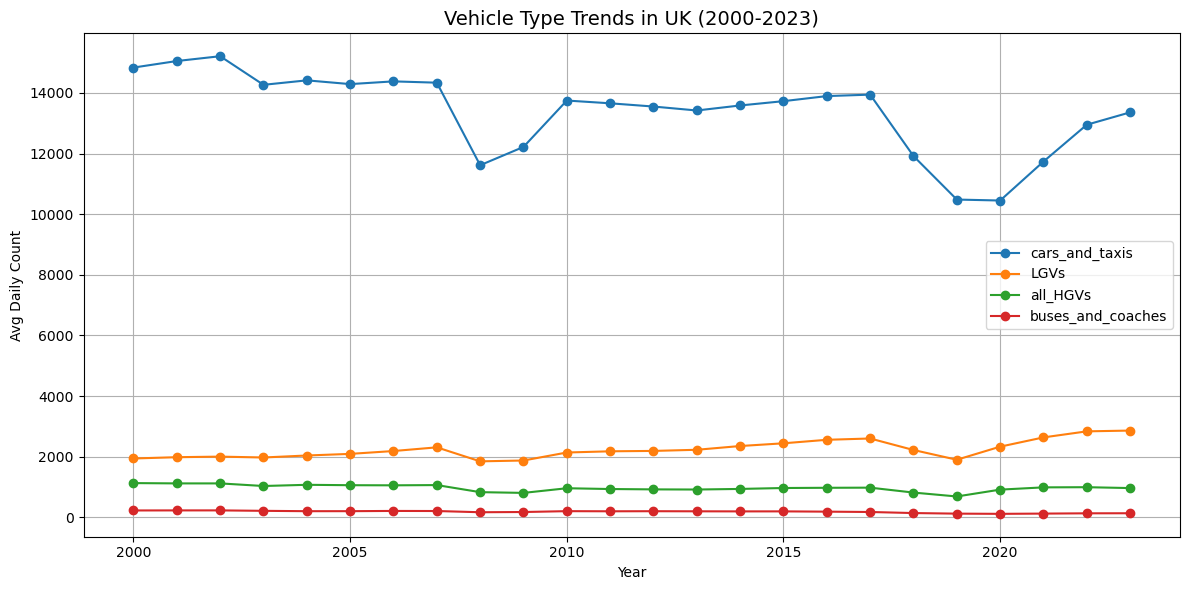

In [7]:
# Compare vehicle types over years
vehicle_cols = ['cars_and_taxis', 'LGVs', 'all_HGVs', 'buses_and_coaches']
yearly_vehicles = df.groupby('year')[vehicle_cols].mean().reset_index()

plt.figure(figsize=(12,6))
for col in vehicle_cols:
    plt.plot(yearly_vehicles['year'], yearly_vehicles[col], marker='o', label=col)

plt.title('Vehicle Type Trends in UK (2000-2023)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Avg Daily Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/04_vehicle_types.png')
plt.show()

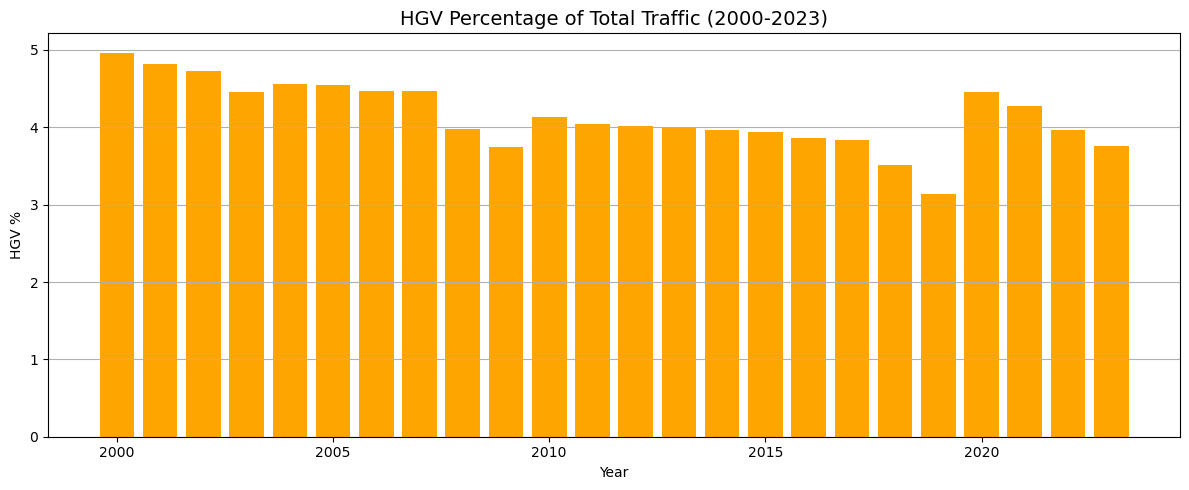

In [8]:
# HGV % of total traffic per year
df['hgv_percentage'] = (df['all_HGVs'] / df['all_motor_vehicles']) * 100

hgv_pct = df.groupby('year')['hgv_percentage'].mean().reset_index()

plt.figure(figsize=(12,5))
plt.bar(hgv_pct['year'], hgv_pct['hgv_percentage'], color='orange')
plt.title('HGV Percentage of Total Traffic (2000-2023)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('HGV %')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('../outputs/05_hgv_percentage.png')
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_5028\252356793.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regional, x='all_motor_vehicles', y='region_name', palette='Blues_r')


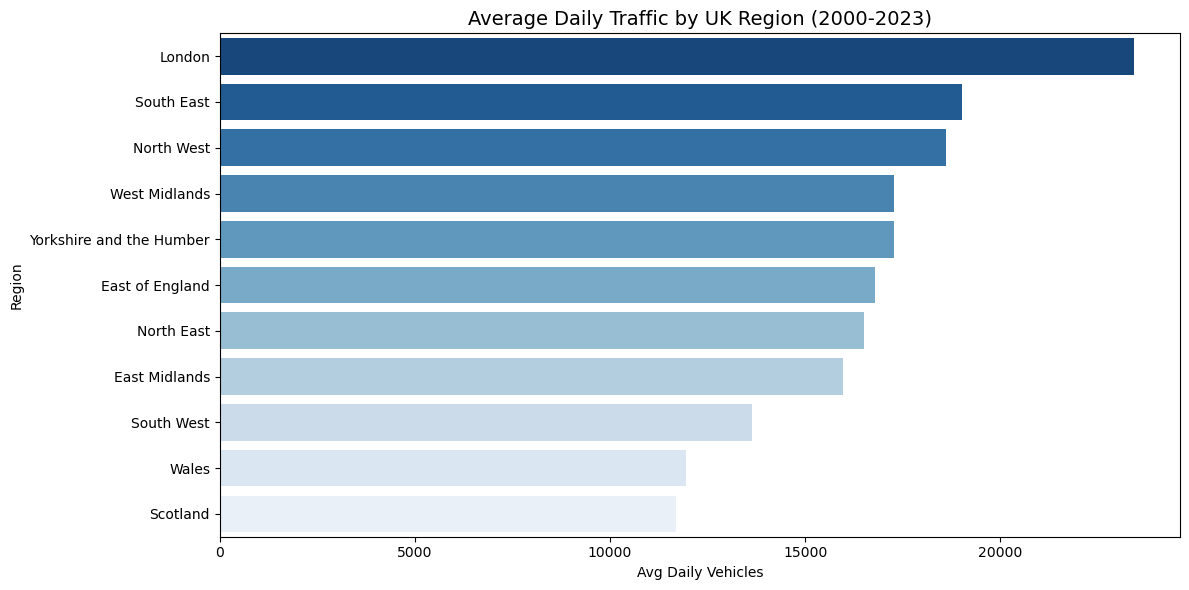

In [9]:
# Average traffic by region
regional = df.groupby('region_name')['all_motor_vehicles'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=regional, x='all_motor_vehicles', y='region_name', palette='Blues_r')
plt.title('Average Daily Traffic by UK Region (2000-2023)', fontsize=14)
plt.xlabel('Avg Daily Vehicles')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('../outputs/06_regional_traffic.png')
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_5028\1479171587.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regional_hgv, x='all_HGVs', y='region_name', palette='Reds_r')


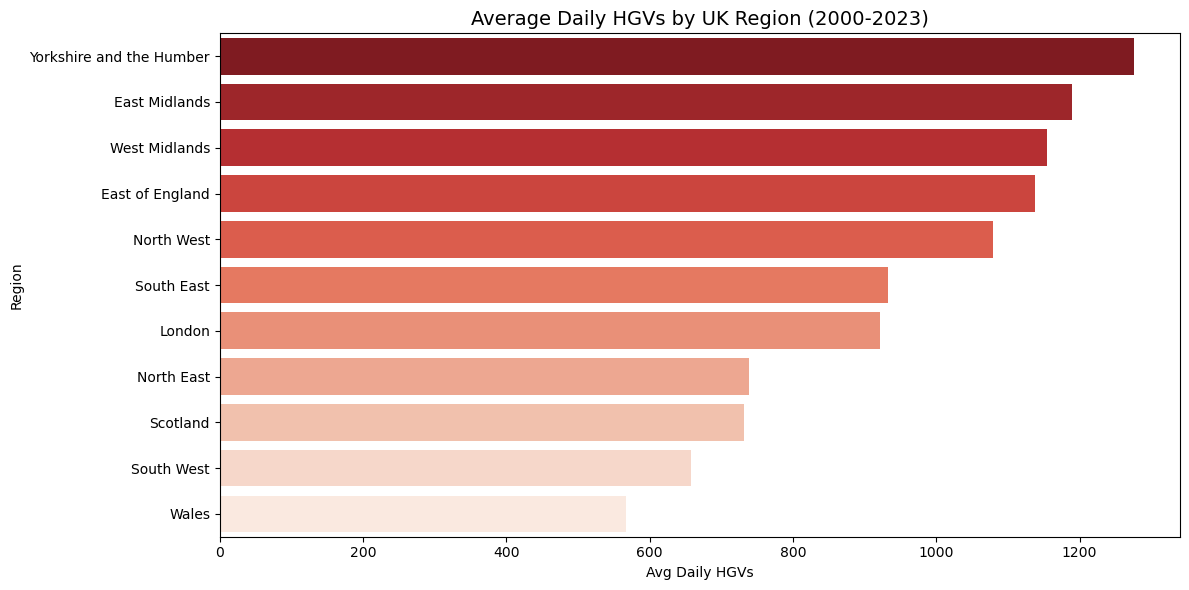

In [10]:
# HGV traffic by region
regional_hgv = df.groupby('region_name')['all_HGVs'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=regional_hgv, x='all_HGVs', y='region_name', palette='Reds_r')
plt.title('Average Daily HGVs by UK Region (2000-2023)', fontsize=14)
plt.xlabel('Avg Daily HGVs')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('../outputs/07_regional_hgv.png')
plt.show()


In [11]:
# Summary statistics for your report
print("=" * 50)
print("KEY FINDINGS SUMMARY")
print("=" * 50)

print(f"\nTotal years of data: {df['year'].min()} - {df['year'].max()}")
print(f"Total road count points: {df['count_point_id'].nunique()}")
print(f"Total regions: {df['region_name'].nunique()}")
print(f"\nAvg HGV % of traffic: {df['hgv_percentage'].mean():.2f}%")
print(f"Max daily vehicles recorded: {df['all_motor_vehicles'].max():,}")
print(f"Max daily HGVs recorded: {df['all_HGVs'].max():,}")
print(f"\nRegions in dataset:")
print(df['region_name'].unique())

KEY FINDINGS SUMMARY

Total years of data: 2000 - 2023
Total road count points: 46025
Total regions: 11

Avg HGV % of traffic: 4.11%
Max daily vehicles recorded: 262,842
Max daily HGVs recorded: 31,198

Regions in dataset:
['South West' 'East Midlands' 'Scotland' 'Wales' 'North West' 'London'
 'East of England' 'Yorkshire and the Humber' 'South East' 'West Midlands'
 'North East']


In [12]:
# Emission factors (grams of CO2 per vehicle per km)
# Source: UK DEFRA/DfT emission factors
emission_factors = {
    'cars_and_taxis': 180,        # g CO2/km
    'buses_and_coaches': 800,     # g CO2/km
    'LGVs': 220,                  # g CO2/km
    'all_HGVs': 900               # g CO2/km (highest!)
}

# Average road length (km) - using link_length_km
# Calculate emissions for each vehicle type
df['emi_cars'] = df['cars_and_taxis'] * emission_factors['cars_and_taxis'] * df['link_length_km']
df['emi_buses'] = df['buses_and_coaches'] * emission_factors['buses_and_coaches'] * df['link_length_km']
df['emi_lgv'] = df['LGVs'] * emission_factors['LGVs'] * df['link_length_km']
df['emi_hgv'] = df['all_HGVs'] * emission_factors['all_HGVs'] * df['link_length_km']

# Total emissions per row (convert grams to tonnes)
df['total_emissions'] = (df['emi_cars'] + df['emi_buses'] + 
                          df['emi_lgv'] + df['emi_hgv']) / 1_000_000

print("Emission columns created successfully!")
print(df[['year','all_HGVs','emi_hgv','total_emissions']].head())

Emission columns created successfully!
   year  all_HGVs  emi_hgv  total_emissions
0  2000        30   8100.0         0.089064
1  2001        28   7560.0         0.090084
2  2002        28   7560.0         0.093324
3  2003        27   7290.0         0.097848
4  2004        84  22680.0         0.076320


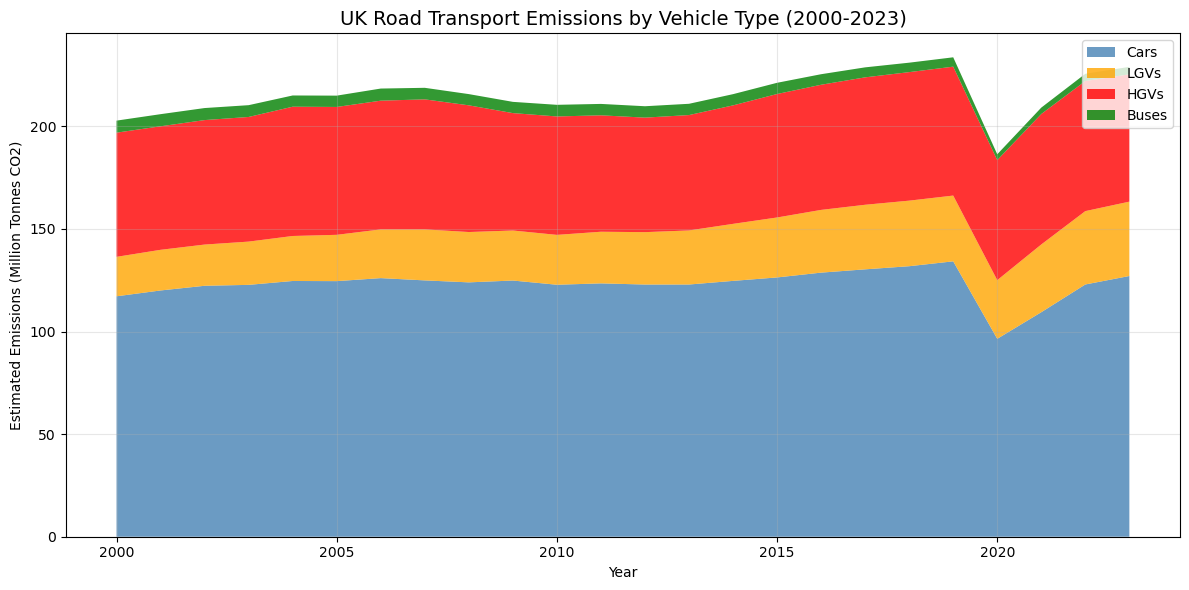

In [13]:
# Yearly emission trends
yearly_emi = df.groupby('year')[['emi_cars','emi_lgv',
                                  'emi_hgv','emi_buses']].sum().reset_index()

# Convert to million tonnes
for col in ['emi_cars','emi_lgv','emi_hgv','emi_buses']:
    yearly_emi[col] = yearly_emi[col] / 1_000_000_000

plt.figure(figsize=(12,6))
plt.stackplot(yearly_emi['year'], 
              yearly_emi['emi_cars'],
              yearly_emi['emi_lgv'],
              yearly_emi['emi_hgv'],
              yearly_emi['emi_buses'],
              labels=['Cars','LGVs','HGVs','Buses'],
              colors=['steelblue','orange','red','green'],
              alpha=0.8)

plt.title('UK Road Transport Emissions by Vehicle Type (2000-2023)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Estimated Emissions (Million Tonnes CO2)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/08_emissions_trend.png')
plt.show()

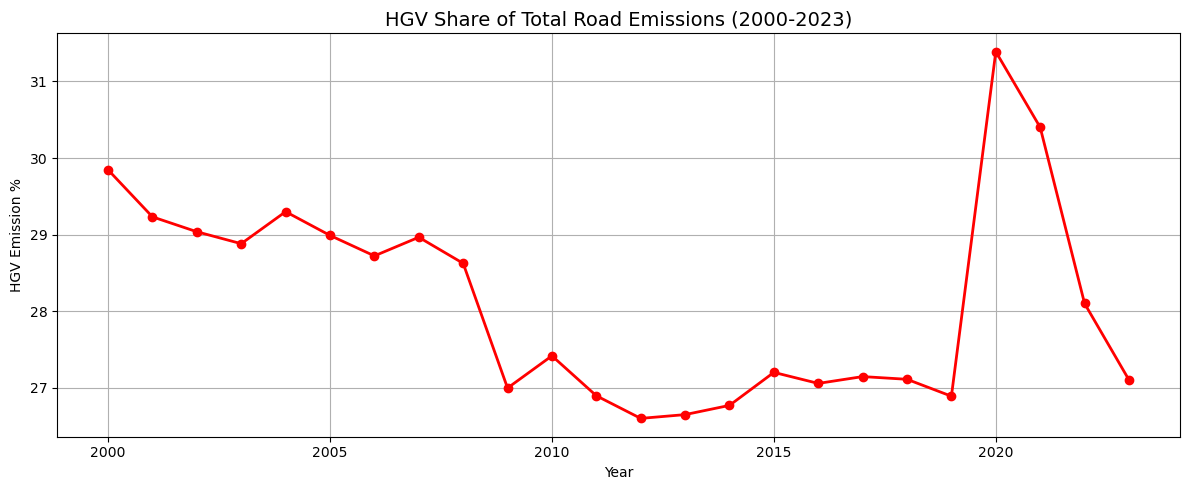


Avg HGV emission share: 28.1%


In [14]:
# HGV share of total emissions per year
yearly_emi['total'] = (yearly_emi['emi_cars'] + yearly_emi['emi_lgv'] + 
                        yearly_emi['emi_hgv'] + yearly_emi['emi_buses'])
yearly_emi['hgv_emi_pct'] = (yearly_emi['emi_hgv'] / yearly_emi['total']) * 100

plt.figure(figsize=(12,5))
plt.plot(yearly_emi['year'], yearly_emi['hgv_emi_pct'], 
         marker='o', color='red', linewidth=2)
plt.title('HGV Share of Total Road Emissions (2000-2023)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('HGV Emission %')
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/09_hgv_emission_share.png')
plt.show()

print(f"\nAvg HGV emission share: {yearly_emi['hgv_emi_pct'].mean():.1f}%")

In [4]:
# Cell 1 — Load everything fresh
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv(
    r'C:\Users\dell\Desktop\FYP_Traffic\data\dft_traffic_counts_aadf.csv',
    low_memory=False)

# Add HGV percentage
df['hgv_percentage'] = (
    df['all_HGVs'] / df['all_motor_vehicles']
) * 100

print(f"✅ Data loaded!")
print(f"Shape: {df.shape}")
print(f"Columns with lat/long: ",
      'latitude' in df.columns,
      'longitude' in df.columns)

✅ Data loaded!
Shape: (555880, 35)
Columns with lat/long:  True True


In [5]:
# Cell 2 — Calculate regional emissions
emission_factors_hgv = 900

df['hgv_emissions_tonnes'] = (
    df['all_HGVs'] *
    emission_factors_hgv *
    df['link_length_km']
) / 1_000_000

regional_emi = df.groupby('region_name').agg(
    total_hgv_emissions=(
        'hgv_emissions_tonnes', 'sum'),
    avg_hgv_pct=(
        'hgv_percentage', 'mean'),
    avg_traffic=(
        'all_motor_vehicles', 'mean')
).reset_index().sort_values(
    'total_hgv_emissions', ascending=False)

print("✅ Regional emissions calculated!")
print(regional_emi)

✅ Regional emissions calculated!
                 region_name  total_hgv_emissions  avg_hgv_pct   avg_traffic
6                 South East        211719.545910     3.155693  19021.496035
1            East of England        179450.472501     4.496821  16786.783725
4                 North West        174250.110321     3.825810  18596.775569
9              West Midlands        167271.226821     4.380907  17273.087901
0              East Midlands        165780.021951     5.206173  15969.539307
10  Yorkshire and the Humber        156465.961974     4.731555  17270.320930
5                   Scotland        131653.382211     5.446234  11690.202252
7                 South West        117230.953887     3.736920  13630.221827
8                      Wales         57654.737676     3.781156  11959.020783
2                     London         52879.166136     3.129272  23432.645305
3                 North East         38530.126584     3.481117  16516.391212


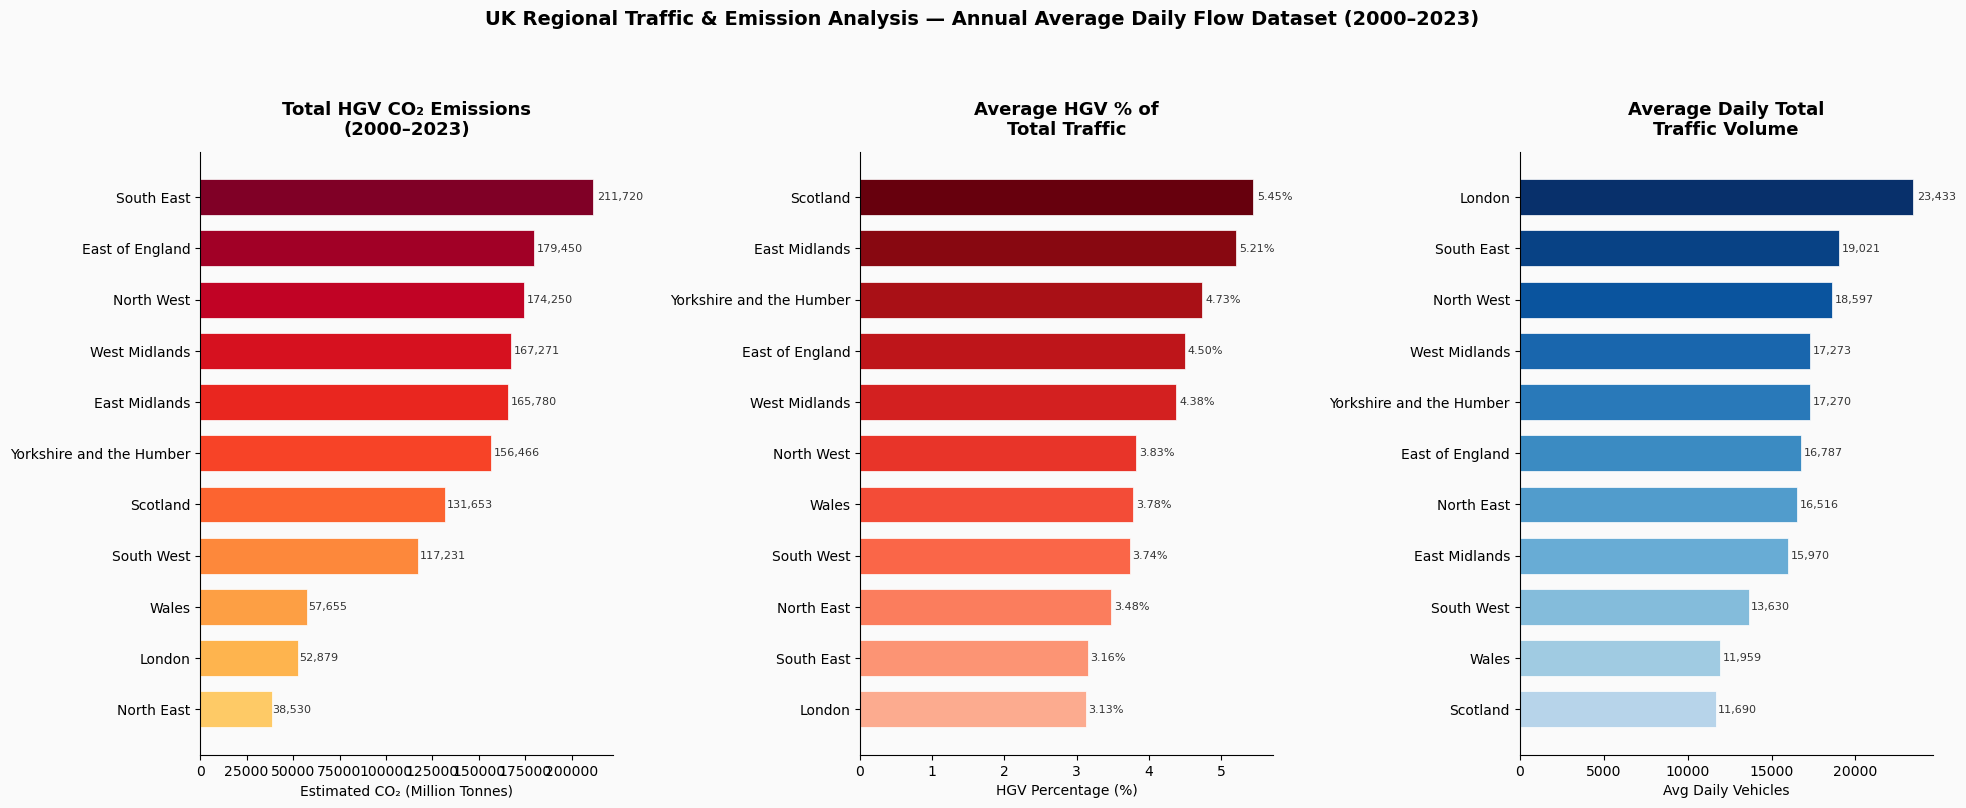

✅ Choropleth chart saved at 300 DPI!


In [8]:
# Cell 3 — Publication quality regional chart
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.patch.set_facecolor('#fafafa')

# Sort data for each chart
emi_sorted  = regional_emi.sort_values('total_hgv_emissions')
hgv_sorted  = regional_emi.sort_values('avg_hgv_pct')
traf_sorted = regional_emi.sort_values('avg_traffic')

colors_emi  = plt.cm.YlOrRd(np.linspace(0.3, 1.0, len(regional_emi)))
colors_hgv  = plt.cm.Reds(np.linspace(0.3, 1.0, len(regional_emi)))
colors_traf = plt.cm.Blues(np.linspace(0.3, 1.0, len(regional_emi)))

# ── Chart 1: Total HGV CO2 Emissions ──
bars1 = axes[0].barh(
    emi_sorted['region_name'],
    emi_sorted['total_hgv_emissions'],
    color=colors_emi, edgecolor='white',
    linewidth=0.5, height=0.7)
axes[0].set_title(
    'Total HGV CO₂ Emissions\n(2000–2023)',
    fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel(
    'Estimated CO₂ (Million Tonnes)', fontsize=10)
axes[0].set_facecolor('#fafafa')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for bar, val in zip(bars1,
        emi_sorted['total_hgv_emissions']):
    axes[0].text(
        bar.get_width() * 1.01,
        bar.get_y() + bar.get_height()/2,
        f'{val:,.0f}', va='center',
        fontsize=8, color='#333')

# ── Chart 2: Average HGV % ──
bars2 = axes[1].barh(
    hgv_sorted['region_name'],
    hgv_sorted['avg_hgv_pct'],
    color=colors_hgv, edgecolor='white',
    linewidth=0.5, height=0.7)
axes[1].set_title(
    'Average HGV % of\nTotal Traffic',
    fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel(
    'HGV Percentage (%)', fontsize=10)
axes[1].set_facecolor('#fafafa')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for bar, val in zip(bars2,
        hgv_sorted['avg_hgv_pct']):
    axes[1].text(
        bar.get_width() * 1.01,
        bar.get_y() + bar.get_height()/2,
        f'{val:.2f}%', va='center',
        fontsize=8, color='#333')

# ── Chart 3: Average Daily Traffic ──
bars3 = axes[2].barh(
    traf_sorted['region_name'],
    traf_sorted['avg_traffic'],
    color=colors_traf, edgecolor='white',
    linewidth=0.5, height=0.7)
axes[2].set_title(
    'Average Daily Total\nTraffic Volume',
    fontsize=13, fontweight='bold', pad=12)
axes[2].set_xlabel(
    'Avg Daily Vehicles', fontsize=10)
axes[2].set_facecolor('#fafafa')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
for bar, val in zip(bars3,
        traf_sorted['avg_traffic']):
    axes[2].text(
        bar.get_width() * 1.01,
        bar.get_y() + bar.get_height()/2,
        f'{val:,.0f}', va='center',
        fontsize=8, color='#333')

plt.suptitle(
    'UK Regional Traffic & Emission Analysis — '
    'Annual Average Daily Flow Dataset (2000–2023)',
    fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout(pad=2.0)
plt.savefig(
    r'C:\Users\dell\Desktop\FYP_Traffic\outputs'
    r'\17_regional_choropleth.png',
    dpi=300, bbox_inches='tight',
    facecolor='#fafafa')
plt.show()
print("✅ Choropleth chart saved at 300 DPI!")

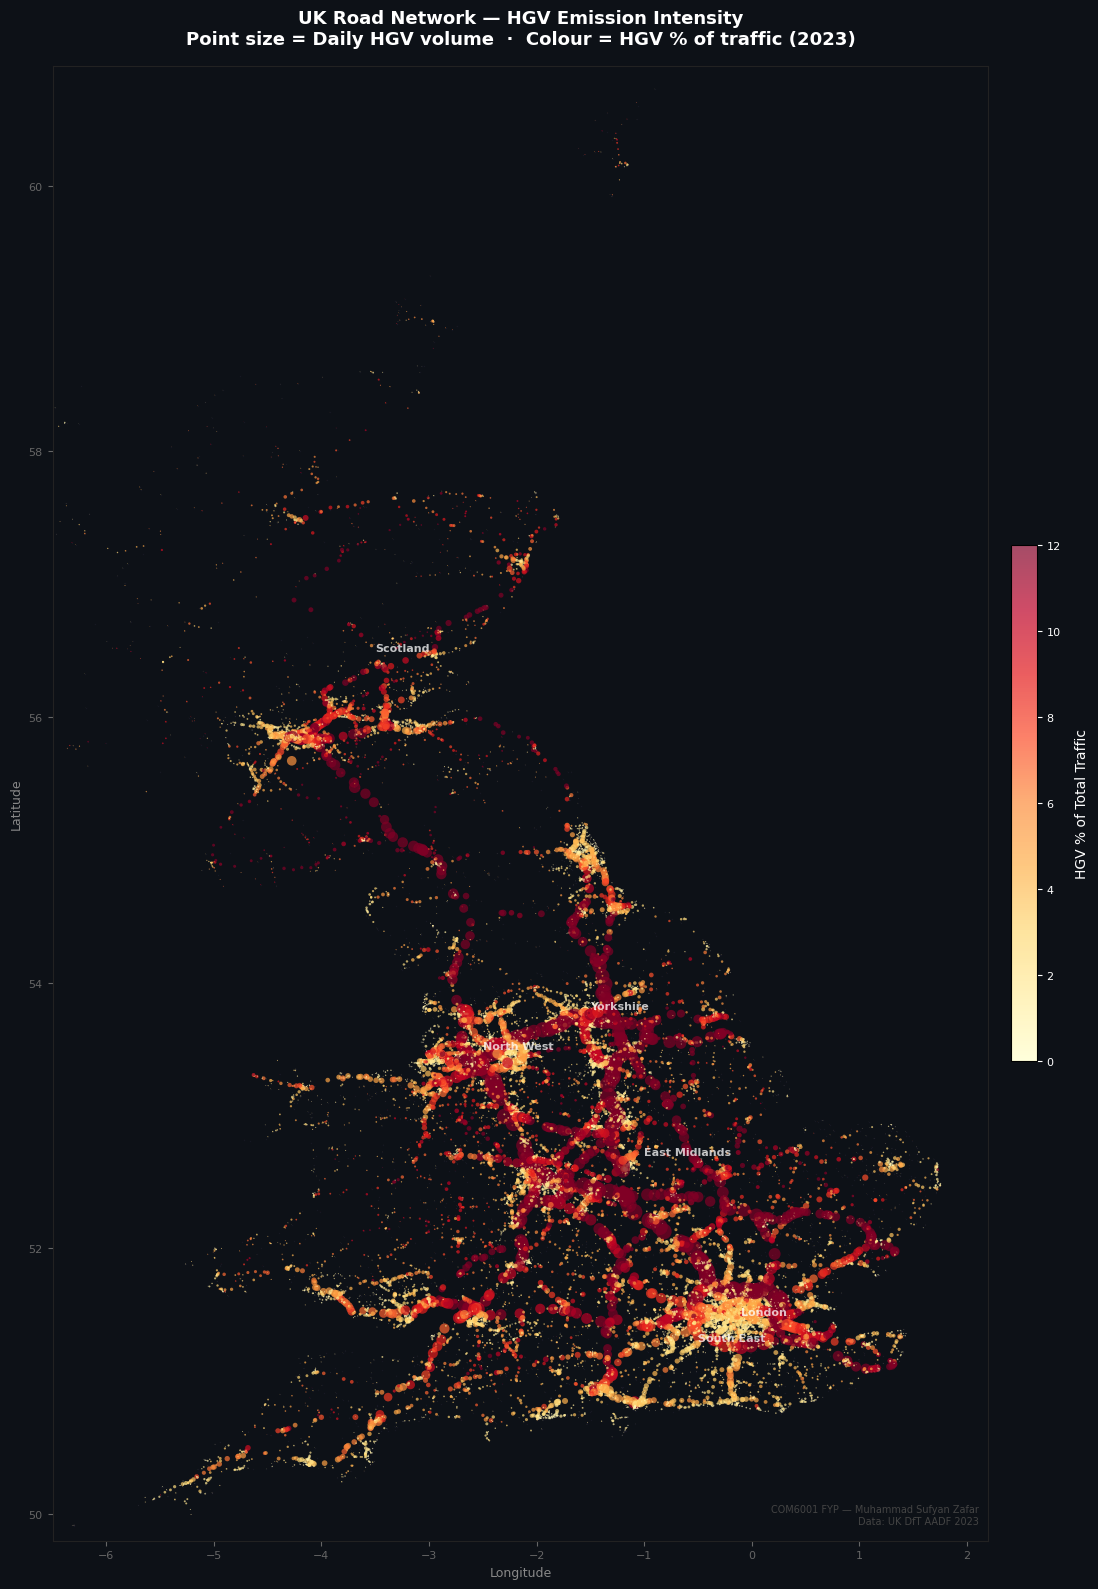

✅ Density map saved at 300 DPI!


In [9]:
# Cell 4 — HGV Intensity Density Map
fig, ax = plt.subplots(
    figsize=(12, 16),
    facecolor='#0d1117')
ax.set_facecolor('#0d1117')

# Use 2023 data only for clearest map
data_2023 = df[
    (df['year'] == 2023) &
    (df['latitude'] != 0) &
    (df['longitude'] != 0) &
    (df['latitude'].notna()) &
    (df['longitude'].notna())
].copy()

# Background all roads — faint grey
ax.scatter(
    data_2023['longitude'],
    data_2023['latitude'],
    c='#2a2a3e',
    alpha=0.3, s=1,
    linewidths=0, zorder=1)

# HGV intensity layer — coloured
mask = data_2023['hgv_percentage'] > 0
scatter = ax.scatter(
    data_2023.loc[mask, 'longitude'],
    data_2023.loc[mask, 'latitude'],
    c=data_2023.loc[mask, 'hgv_percentage'],
    cmap='YlOrRd',
    alpha=0.7,
    s=data_2023.loc[mask, 'all_HGVs'] / 150,
    linewidths=0,
    vmin=0, vmax=12,
    zorder=2)

# Highlight top emission regions
top_regions = {
    'South East':   (-0.5,  51.3),
    'East Midlands':(-1.0,  52.7),
    'North West':   (-2.5,  53.5),
    'Scotland':     (-3.5,  56.5),
    'London':       (-0.1,  51.5),
    'Yorkshire':    (-1.5,  53.8),
}
for region, (lon, lat) in top_regions.items():
    ax.annotate(
        region,
        xy=(lon, lat),
        color='rgba(255,255,255,0.7)'
        if False else '#ffffff',
        fontsize=8,
        fontweight='bold',
        alpha=0.75,
        zorder=5)

# Colorbar
cbar = plt.colorbar(
    scatter, ax=ax,
    shrink=0.35, pad=0.02,
    orientation='vertical')
cbar.set_label(
    'HGV % of Total Traffic',
    color='white', fontsize=10,
    labelpad=10)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(
    plt.getp(cbar.ax.axes, 'yticklabels'),
    color='white', fontsize=8)

# Title and labels
ax.set_title(
    'UK Road Network — HGV Emission Intensity\n'
    'Point size = Daily HGV volume  ·  '
    'Colour = HGV % of traffic (2023)',
    color='white', fontsize=13,
    fontweight='bold', pad=16)
ax.set_xlabel('Longitude', color='#888', fontsize=9)
ax.set_ylabel('Latitude',  color='#888', fontsize=9)
ax.tick_params(colors='#666', labelsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor('#222')

# UK boundary box
ax.set_xlim(-6.5, 2.2)
ax.set_ylim(49.8, 60.9)

# Watermark
ax.text(
    0.99, 0.01,
    'COM6001 FYP — Muhammad Sufyan Zafar\n'
    'Data: UK DfT AADF 2023',
    transform=ax.transAxes,
    color='#444', fontsize=7,
    ha='right', va='bottom')

plt.tight_layout()
plt.savefig(
    r'C:\Users\dell\Desktop\FYP_Traffic\outputs'
    r'\18_hgv_density_map.png',
    dpi=300, bbox_inches='tight',
    facecolor='#0d1117')
plt.show()
print("✅ Density map saved at 300 DPI!")

In [10]:
# Cell 5 — Export for Kepler.gl
map_export = df[
    (df['latitude'].notna()) &
    (df['longitude'].notna()) &
    (df['latitude'] != 0) &
    (df['longitude'] != 0)
][[
    'latitude', 'longitude',
    'region_name', 'road_category',
    'year', 'all_HGVs',
    'all_motor_vehicles',
    'hgv_percentage',
    'link_length_km',
    'hgv_emissions_tonnes'
]].copy()

# Save full dataset
map_export.to_csv(
    r'C:\Users\dell\Desktop\FYP_Traffic\outputs'
    r'\kepler_all_years.csv',
    index=False)

# Save 2023 only — easier to load in Kepler
map_export[map_export['year']==2023].to_csv(
    r'C:\Users\dell\Desktop\FYP_Traffic\outputs'
    r'\kepler_2023.csv',
    index=False)

print("✅ Kepler CSV files saved!")
print(f"All years: {len(map_export):,} records")
print(f"2023 only: "
      f"{len(map_export[map_export['year']==2023]):,}"
      f" records")

✅ Kepler CSV files saved!
All years: 555,880 records
2023 only: 22,257 records
